In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/social_media_addiction_dataset (1).csv')
df.head()

,daily_screen_time,app_opens,sleep_hours,stress_level,study_interruptions,night_usage,addiction_level
0,5.4,67,3.8,1,2,No,Moderate
1,4.3,10,6.9,2,7,No,Low
2,7.0,48,5.4,9,3,No,Moderate
3,12.0,16,6.7,2,0,No,Low
4,8.8,25,6.0,3,15,No,Moderate


In [5]:
X = df.drop('addiction_level', axis=1)

In [7]:
X = pd.get_dummies(X)

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

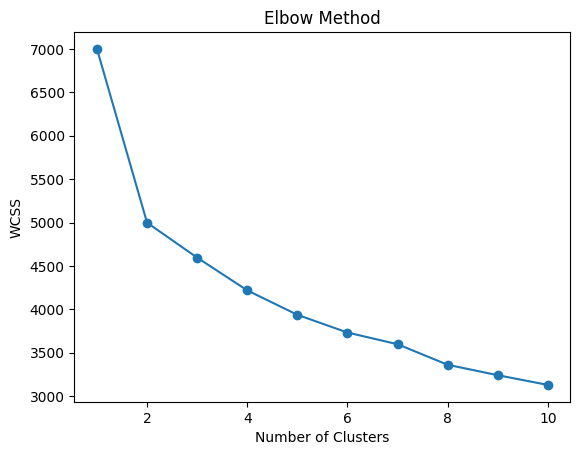

In [16]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [17]:
model = KMeans(
    n_clusters=3,
    random_state=42
)
model.fit(X_scaled)

KMeans(n_clusters=3, random_state=42)

In [18]:
clusters = model.labels_
print(clusters)

[2 1 2 1 2 0 1 0 1 2 0 0 0 2 0 0 0 0 0 0 0 1 1 2 0 1 0 0 0 0 0 0 1 0 1 2 1
 0 2 2 2 2 2 0 1 0 0 0 2 0 0 2 0 1 2 0 0 1 2 0 2 2 0 2 0 1 1 0 1 0 1 1 0 2
 0 0 0 1 1 2 2 1 0 1 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 0 0 2 2 0 0 0 0 0 0 1 0
 0 2 0 1 0 1 0 0 0 1 0 2 0 1 0 0 1 0 0 1 0 0 0 2 0 0 1 1 0 0 1 0 0 2 1 2 2
 2 1 2 0 0 0 2 2 0 0 1 2 2 1 1 0 2 2 1 1 0 0 0 0 2 1 0 0 1 0 0 1 2 2 0 0 0
 1 2 1 1 2 1 2 1 1 0 2 0 0 0 2 0 2 0 0 2 0 2 1 1 0 0 0 0 0 2 0 0 2 1 1 2 0
 2 2 2 0 0 2 0 2 2 0 0 0 0 0 0 0 1 0 0 0 1 2 2 0 0 2 2 0 1 1 2 0 2 2 0 1 0
 2 2 0 0 1 2 1 0 0 2 2 0 0 2 0 2 0 1 1 0 0 0 0 0 0 1 1 2 0 0 0 0 0 1 1 0 1
 1 1 1 1 1 1 1 2 0 2 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1 2 0 0 0 0 0 0 0 0 2 0 0
 1 2 1 0 0 1 0 0 0 0 2 1 0 2 0 1 0 0 1 0 1 1 2 1 0 1 0 0 1 2 0 2 1 2 2 0 2
 0 1 0 2 0 2 0 1 0 0 2 1 0 0 0 2 0 1 1 0 1 2 0 2 2 0 0 1 1 1 1 0 0 2 1 2 0
 0 0 0 0 1 2 0 1 0 2 1 0 0 1 1 1 2 0 0 2 0 0 0 2 0 1 0 1 2 2 1 0 1 2 0 1 0
 0 0 0 2 0 2 0 2 0 0 0 0 1 0 0 2 2 0 2 0 2 0 0 1 0 1 2 0 1 1 1 0 2 1 0 0 0
 2 2 0 0 2 1 0 2 0 0 0 2 

In [19]:
df['Cluster'] = clusters
df.head()

,daily_screen_time,app_opens,sleep_hours,stress_level,study_interruptions,night_usage,addiction_level,Cluster
0,5.4,67,3.8,1,2,No,Moderate,2
1,4.3,10,6.9,2,7,No,Low,1
2,7.0,48,5.4,9,3,No,Moderate,2
3,12.0,16,6.7,2,0,No,Low,1
4,8.8,25,6.0,3,15,No,Moderate,2


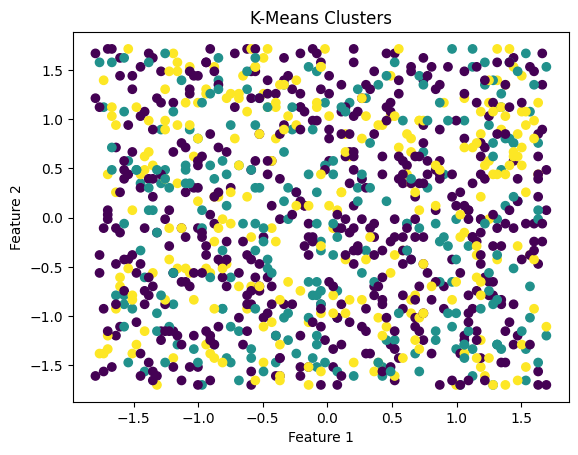

In [20]:
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters
)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clusters')
plt.show()

In [21]:
print(model.cluster_centers_)

[[-0.01121897 -0.01790257 -0.01446434 -0.02378365  0.02589991 -1.040833
   1.040833  ]
 [-0.00147594 -0.07165347  0.82812351 -0.22190769 -0.23192729  0.96076892
  -0.96076892]
 [ 0.02218788  0.10470436 -0.80142011  0.26581597  0.18411206  0.96076892
  -0.96076892]]


In [23]:
import joblib
joblib.dump(model, 'kmeans_own.joblib')

['kmeans_own.joblib']